In [281]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [282]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

In [283]:
header = "D:/K_sunada/database/"
t1 ="/2023-06-22/2023-06-22T164357_8b838d16-td_ge_T1"

dd_t1 = datadict_from_hdf5(header + t1 +"/data")

T1

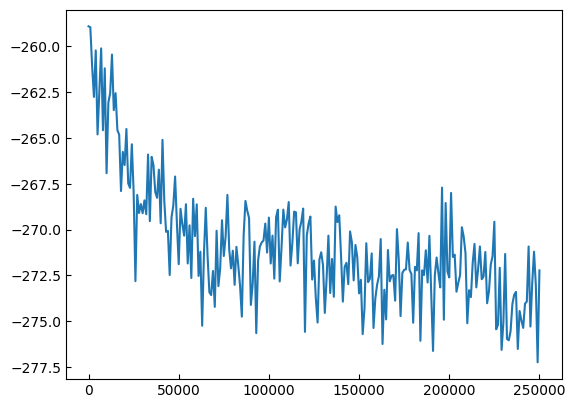

In [284]:
s11_t1 = dd_t1['s11']['values']
imag_t1 = s11_t1.imag
delay_t1 = dd_t1['delay']['values']

plt.plot(delay_t1, imag_t1)
plt.show()

In [285]:
import sklearn
from sklearn.decomposition import PCA

In [286]:
I = (s11_t1.real)
Q = (s11_t1.imag)

In [287]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [288]:
PCAge = PCA_transform(I, Q)

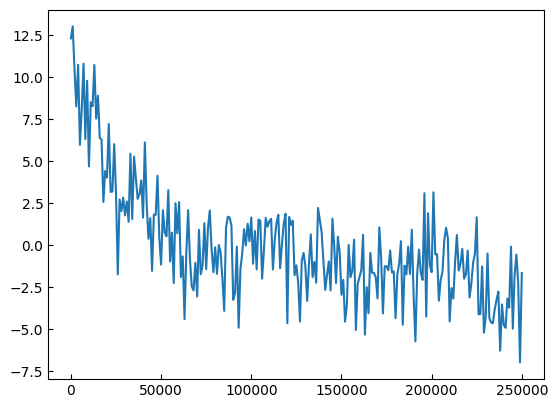

In [289]:
y = PCAge[0]
x = delay_t1

plt.plot(x, y)
plt.show()

In [290]:
par_ini = {
    'gamma': 1/40000,
    'amp':14.5,
    'const':-2.5
}

par_min = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [291]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [292]:
result_t1 = model.fit(data = y, params = params, delay = x)

In [293]:
result_t1

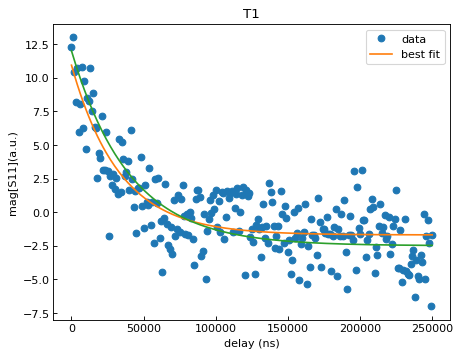

In [294]:
fig, ax = plt.subplots(dpi=80)

plt.title("T1")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t1.plot_fit(ax = ax)
plt.plot(delay_t1,result_t1.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()

In [295]:
T1 = (1/3.0133e-5)*1e-9	
T1

3.318620781203332e-05

T2_star

In [296]:
def Damping(delay, amp, gamma, omega, phi0, const):
    return const + amp * np.exp(- gamma*delay)*np.cos(omega*delay + phi0)

In [297]:
header = "D:/K_sunada/database/"
t2 ="2023-06-22/2023-06-22T183627_42f3373c-td_ge_T2r1d"

dd_t2 = datadict_from_hdf5(header + t2 +"/data")

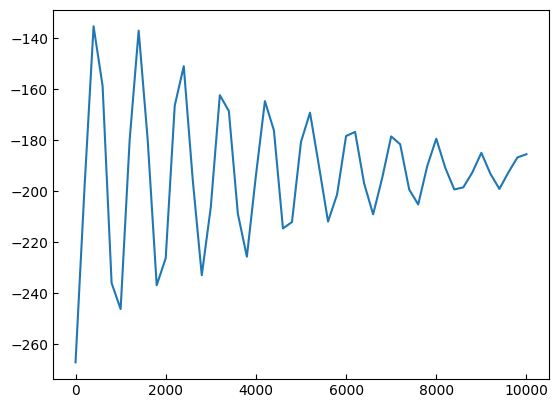

In [298]:
s11_t2 = dd_t2['s11']['values']
imag_t2 = s11_t2.imag
delay_t2 = dd_t2['delay']['values']

plt.plot(delay_t2, imag_t2)
plt.show()

In [299]:
I_t2 = (s11_t2.real)
Q_t2 = (s11_t2.imag)

In [300]:
PCAt2 = PCA_transform(I_t2, Q_t2)

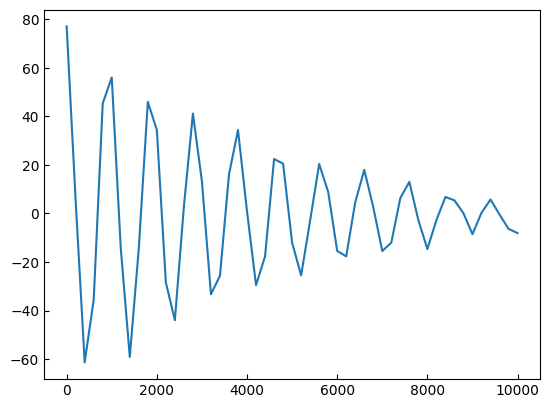

In [301]:
y_t2 = PCAt2[0]
x_t2 = delay_t2

plt.plot(x_t2, y_t2)
plt.show()

In [302]:
par_ini = {
    'amp':-80,
    'gamma': 1/8000,
    'omega':2*np.pi/1200,
    'phi0':np.pi,
    'const':0
}

par_min = {
    'amp':-np.inf,
    'gamma': 0,
    'omega':-2*np.pi,
    'phi0':-2*np.pi,
    'const':-np.inf
}

par_max = {
    'amp':np.inf,
    'gamma': np.inf,
    'omega':2*np.pi,
    'phi0':2*np.pi,
    'const':np.inf
}

par_vary = {
    'amp':True,
    'gamma': True,
    'omega':True,
    'phi0':True,
    'const':True
}

In [303]:
model = lmfit.Model(Damping)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )


In [304]:
result_t2 = model.fit(data = y_t2, params = params, delay = x_t2)
result_t2

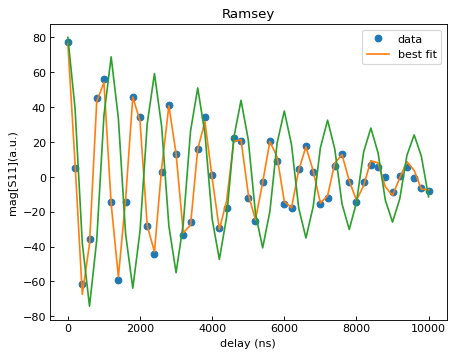

In [305]:
fig, ax = plt.subplots(dpi=80)

plt.title("Ramsey")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2.plot_fit(ax = ax)
plt.plot(delay_t2,result_t2.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()

In [306]:
T2_star = (1/2.2328e-4)*1e-9	
T2_star

4.478681476173415e-06

T2

In [307]:
t2e = "2023-06-22/2023-06-22T185526_e9a5da32-td_ge_T2e"
dd_t2e = datadict_from_hdf5(header + t2e +"/data")

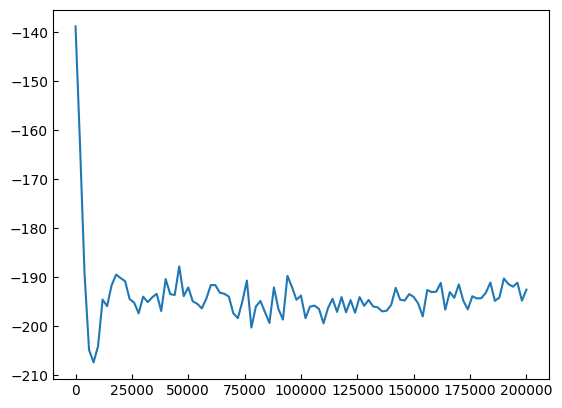

In [308]:
s11_t2e = dd_t2e['s11']['values']
imag_t2e = s11_t2e.imag
delay_t2e = dd_t2e['delay']['values']

plt.plot(delay_t2e, imag_t2e)
plt.show()

In [309]:
I_t2e = (s11_t2e.real)
Q_t2e = (s11_t2e.imag)

In [310]:
PCAt2e = PCA_transform(I_t2e, Q_t2e)

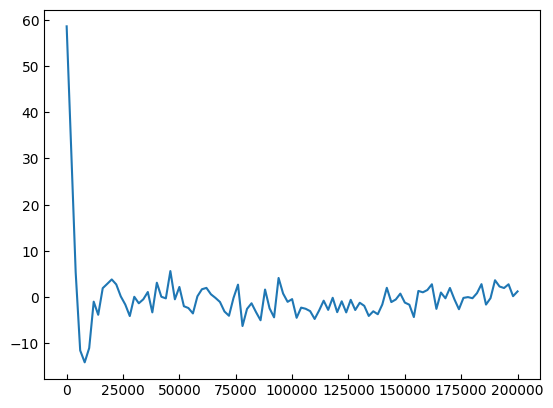

In [311]:
y_t2e = PCAt2e[0]
x_t2e = delay_t2e

plt.plot(x_t2e, y_t2e)
plt.show()

In [312]:
par_ini = {
    'gamma': 1/20000,
    'amp':60,
    'const':0
}

par_min = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [313]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [316]:
result_t2e = model.fit(data = y_t2e, params = params, delay = x_t2e)
result_t2e

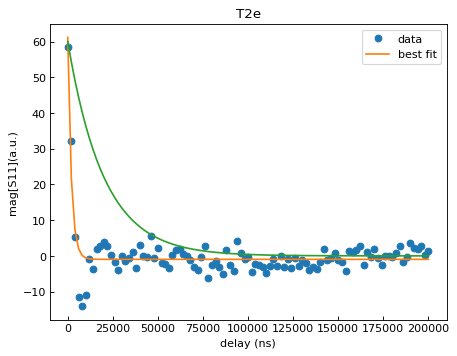

In [317]:
fig, ax = plt.subplots(dpi=80)

plt.title("T2e")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2e.plot_fit(ax = ax)
plt.plot(delay_t2e,result_t2e.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()

In [318]:
T2 = (1/5.0489e-4)*1e-9	
T2

1.980629444037315e-06